In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("Scaled_final_airbnb.csv")
df.dtypes

log_price                    float64
accommodates                 float64
bathrooms                    float64
cancellation_policy            int64
cleaning_fee                   int64
host_has_profile_pic           int64
host_identity_verified         int64
host_response_rate           float64
instant_bookable               int64
latitude                     float64
longitude                    float64
review_scores_rating         float64
bedrooms                     float64
beds                         float64
has_url                        int64
days_since_host              float64
days_since_last_review       float64
days_since_first_review      float64
property_type_Condominium      int64
property_type_House            int64
property_type_Loft             int64
property_type_Other            int64
property_type_Townhouse        int64
room_type_Private room         int64
room_type_Shared room          int64
city_Chicago                   int64
city_DC                        int64
c

In [5]:
luxury_features = [
     'accommodates', 'bathrooms', 'bedrooms',
    'cleaning_fee','cancellation_policy', 'host_response_rate', 'review_scores_rating',
    'instant_bookable', 'property_type_Condominium', 'property_type_House',
    'property_type_Loft', 'property_type_Townhouse','room_type_Private room',
    'city_Chicago', 'city_DC', 'city_LA', 'city_NYC', 'city_SF', 'bed_type_Real Bed'
]
X = df[luxury_features]

C:\Users\avant\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\avant\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\avant\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\avant\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\avant\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

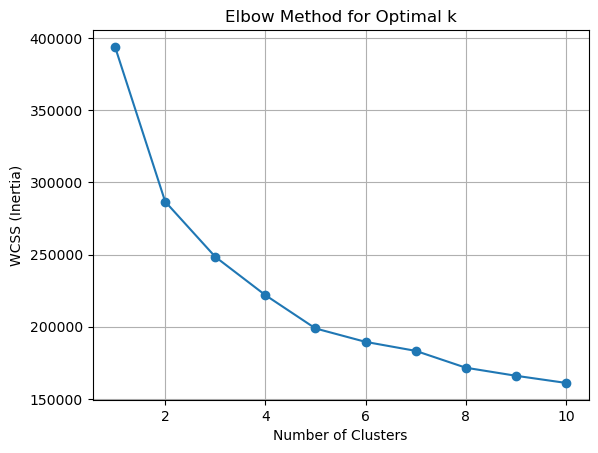

In [7]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()


In [9]:
from kneed import KneeLocator  # Make sure to install with: pip install kneed
# Elbow method - compute inertia
inertia = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, init="k-means++")
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Use KneeLocator to find the elbow point
knee = KneeLocator(cluster_range, inertia, curve="convex", direction="decreasing")
optimal_k = knee.elbow
print(f"Optimal number of clusters according to KneeLocator: {optimal_k}")

Optimal number of clusters according to KneeLocator: 4


In [11]:
kmeans = KMeans(n_clusters=4, random_state=42,init="k-means++")
X['cluster']= kmeans.fit_predict(X)

C:\Users\avant\AppData\Local\Temp\ipykernel_21484\2642622380.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster']= kmeans.fit_predict(X)


In [37]:
X['cluster'].value_counts()

cluster
2    25864
0    21458
3    17146
1     9643
Name: count, dtype: int64

C:\Users\avant\AppData\Local\Temp\ipykernel_21484\1902757559.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['pca1'] = pca_result[:, 0]
C:\Users\avant\AppData\Local\Temp\ipykernel_21484\1902757559.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['pca2'] = pca_result[:, 1]


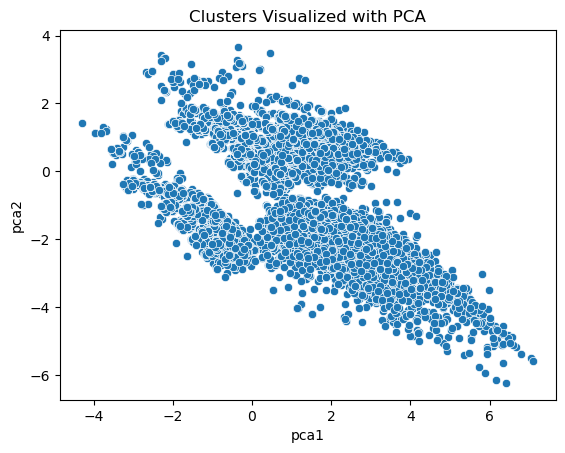

In [15]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
X['pca1'] = pca_result[:, 0]
X['pca2'] = pca_result[:, 1]

sns.scatterplot(data=X, x='pca1', y='pca2')
plt.title('Clusters Visualized with PCA')
plt.show()

C:\Users\avant\AppData\Local\Temp\ipykernel_21484\3478327952.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['pca1'] = pca_result[:, 0]
C:\Users\avant\AppData\Local\Temp\ipykernel_21484\3478327952.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['pca2'] = pca_result[:, 1]


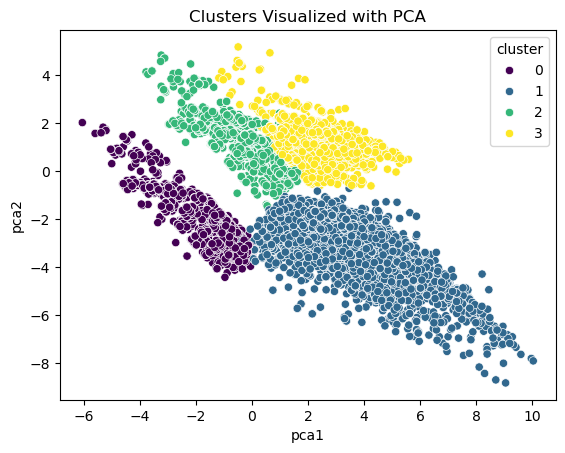

In [17]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
X['pca1'] = pca_result[:, 0]
X['pca2'] = pca_result[:, 1]

sns.scatterplot(data=X, x='pca1', y='pca2', hue='cluster', palette='viridis')
plt.title('Clusters Visualized with PCA')
plt.show()


In [19]:
df['cluster']=X['cluster']

C:\Users\avant\AppData\Local\Temp\ipykernel_21484\1449337284.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='cluster', y='log_price', palette='viridis')


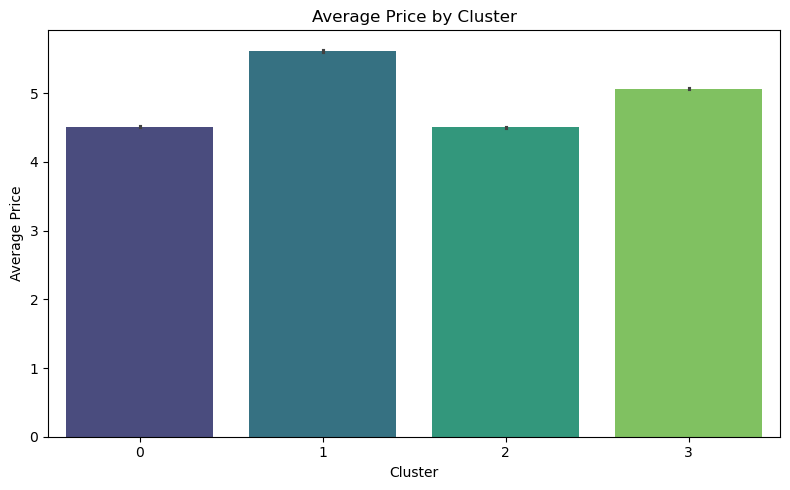

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a barplot of average price by cluster
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='cluster', y='log_price', palette='viridis')

plt.title('Average Price by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()


C:\Users\avant\AppData\Local\Temp\ipykernel_21484\249713503.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='cluster', y='accommodates', palette='viridis')


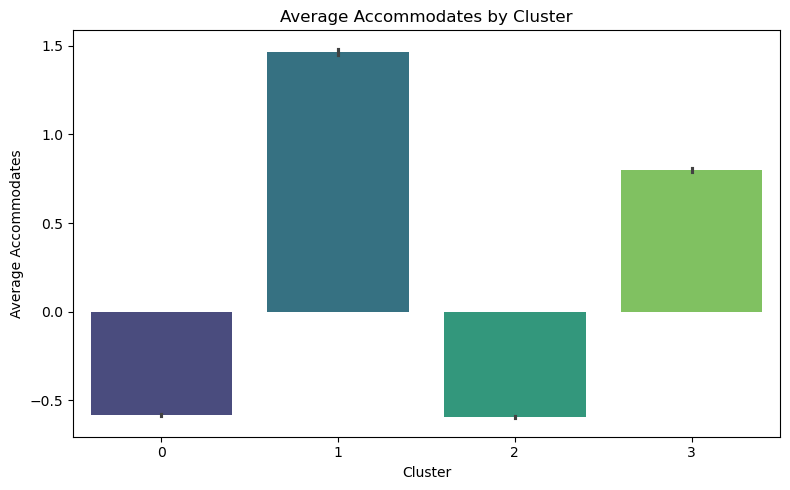

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a barplot of average accommodates by cluster
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='cluster', y='accommodates', palette='viridis')

plt.title('Average Accommodates by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Accommodates')
plt.tight_layout()
plt.show()

In [25]:
cols_to_count = [
    'property_type_Condominium',
    'property_type_House',
    'property_type_Loft',
    'property_type_Other',
    'property_type_Townhouse',
    'room_type_Private room',
    'room_type_Shared room'
]
# Group by cluster and sum each column
property_room_counts = df.groupby('cluster')[cols_to_count].sum().astype(int)

# Display the result
property_room_counts

,property_type_Condominium,property_type_House,property_type_Loft,property_type_Other,property_type_Townhouse,room_type_Private room,room_type_Shared room
cluster,,,,,,,
0,627,4188,275,844,362,13508,987
1,601,4339,135,331,472,624,176
2,833,5165,479,1165,543,15132,838
3,597,2819,355,663,315,1374,162


In [27]:
# Average values per cluster
cluster_summary = df.groupby('cluster')[luxury_features].mean()
cluster_summary

,accommodates,bathrooms,bedrooms,cleaning_fee,cancellation_policy,host_response_rate,review_scores_rating,instant_bookable,property_type_Condominium,property_type_House,property_type_Loft,property_type_Townhouse,room_type_Private room,city_Chicago,city_DC,city_LA,city_NYC,city_SF,bed_type_Real Bed
cluster,,,,,,,,,,,,,,,,,,,
0,-0.581823,-0.293038,-0.346296,0.419238,0.117252,0.922385,0.940301,0.252493,0.029220,0.195172,0.012816,0.016870,0.629509,0.042269,0.082673,0.288704,0.472271,0.076894,0.959502
1,1.465833,2.078719,1.485530,0.844965,1.407342,0.948152,0.943105,0.261018,0.062325,0.449964,0.014000,0.048947,0.064710,0.071762,0.107228,0.463030,0.199627,0.106191,0.995437
2,-0.593993,-0.288352,-0.546632,0.867151,1.645376,0.951916,0.941823,0.252127,0.032207,0.199698,0.018520,0.020994,0.585060,0.040945,0.053588,0.284488,0.487550,0.087496,0.962225
3,0.799765,-0.367383,0.422486,0.864983,1.491427,0.954699,0.938039,0.291322,0.034819,0.164412,0.020705,0.018372,0.080135,0.061880,0.087134,0.258661,0.447918,0.087309,0.988744


# 🧠 Cluster Interpretation

## 🔵 Cluster 0: Budget-Friendly Private Rooms in NYC
- **Size:** Small-sized listings (fewer rooms and bathrooms).
- **Fees:** Slightly higher cleaning fee, moderately strict cancellation.
- **Quality:** Very responsive hosts and high review scores.
- **Room Type:** Mostly private rooms.
- **Location:** Primarily in **New York City**, with some in San Francisco.
- **Comfort:** Almost all listings have real beds.

✅ **Ideal for:** Solo or couple travelers seeking affordable, quality private rooms in NYC.

---

## 🟢 Cluster 1: Luxury Entire Homes (LA/NYC)
- **Size:** Very spacious listings with multiple bedrooms and bathrooms.
- **Fees:** High cleaning fee and very strict cancellation policy.
- **Property Type:** Predominantly **entire houses**.
- **Room Type:** Not private rooms – mostly entire properties.
- **Location:** Mostly in **Los Angeles**, followed by NYC.
- **Comfort:** All listings have proper beds.

✅ **Ideal for:** Families or groups looking for premium stays in LA or NYC.

---

## 🟡 Cluster 2: Clean, Affordable Rooms with Great Hosts
- **Size:** Small, compact listings.
- **Fees:** High cleaning fee with very strict cancellation policy.
- **Quality:** Excellent host responsiveness and guest ratings.
- **Room Type:** Mostly private rooms.
- **Location:** Primarily **New York City**, some presence in San Francisco.
- **Comfort:** Almost all have real beds.

✅ **Ideal for:** Budget-conscious travelers who prioritize host quality and cleanliness.

---

## 🟠 Cluster 3: Mid-Sized Modern Rentals / Condos
- **Size:** Medium-sized listings (fewer bathrooms but decent room count).
- **Fees:** High cleaning fee and strict cancellation.
- **Booking:** More listings available for instant booking.
- **Location:** Largely in **NYC**.
- **Comfort:** Nearly all listings offer real beds.

✅ **Ideal for:** Business travelers or digital nomads seeking modern rentals with flexibility.

---

## 📊 Summary Table

| Cluster | Summary |
|--------|---------|
| **0** | Compact, highly rated **private rooms** for budget-conscious NYC travelers. |
| **1** | **Spacious luxury homes**, mostly in LA and NYC – ideal for groups. |
| **2** | Affordable, small, clean **private rooms** with strict rules, mostly in NYC. |
| **3** | Mid-sized, modern **condos/apartments**, more flexible booking, mostly in NYC. |



In [30]:
# Average values per cluster
cluster_summary = df.groupby('cluster').mean()
cluster_summary

,log_price,accommodates,bathrooms,cancellation_policy,cleaning_fee,host_has_profile_pic,host_identity_verified,host_response_rate,instant_bookable,latitude,...,city_Chicago,city_DC,city_LA,city_NYC,city_SF,bed_type_Couch,bed_type_Futon,bed_type_Pull-out Sofa,bed_type_Real Bed,log_number_of_reviews
cluster,,,,,,,,,,,,,,,,,,,,,
0,4.513683,-0.581823,-0.293038,0.117252,0.419238,0.991798,0.555644,0.922385,0.252493,38.535981,...,0.042269,0.082673,0.288704,0.472271,0.076894,0.006664,0.013981,0.009460,0.959502,-0.451681
1,5.617500,1.465833,2.078719,1.407342,0.844965,0.995126,0.706004,0.948152,0.261018,37.297377,...,0.071762,0.107228,0.463030,0.199627,0.106191,0.000519,0.001763,0.001037,0.995437,-0.072734
2,4.506539,-0.593993,-0.288352,1.645376,0.867151,0.995476,0.723709,0.951916,0.252127,38.598003,...,0.040945,0.053588,0.284488,0.487550,0.087496,0.003596,0.014886,0.011638,0.962225,0.246051
3,5.063726,0.799765,-0.367383,1.491427,0.864983,0.995684,0.717310,0.954699,0.291322,38.749911,...,0.061880,0.087134,0.258661,0.447918,0.087309,0.001575,0.002974,0.004141,0.988744,0.235022


In [32]:
from sklearn.metrics import silhouette_score
# Compute silhouette score for PCA components and cluster labels
sil_score_pca = silhouette_score(X[['pca1', 'pca2']], X['cluster'])
print(f"Silhouette Score for PCA components: {sil_score_pca:.4f}")

Silhouette Score for PCA components: 0.5908


In [34]:

from sklearn.metrics import davies_bouldin_score

# Compute Davies-Bouldin Index
db_index = davies_bouldin_score(X[['pca1', 'pca2']], X['cluster'])
print(f"Davies-Bouldin Index: {db_index:.4f}")

Davies-Bouldin Index: 0.5893


## 📈 Cluster Validation Metrics

To assess the quality and separability of the clusters, we used the following evaluation metrics:

- **Silhouette Score:** `0.5908`
- **Davies-Bouldin Index (DBI):** `0.5893`

### ✅ Interpretation:
- A **Silhouette Score** of **~0.59** indicates that the clusters are **well-formed and distinct**, suggesting that data points are close to their own cluster and far from other clusters.
- A **Davies-Bouldin Index** closer to **0** (like **0.5893**) implies **good intra-cluster similarity and inter-cluster separation**.
- From the **PCA visualization**, the clusters are **visibly well-separated**, further confirming the quality of the clustering.

📌 **Conclusion:**  
The combination of **quantitative scores** and **visual validation** suggests that the current clustering is both **meaningful** and **reliable** for interpretation and further analysis.
